In [1]:
%load_ext autoreload

%autoreload 2
import numpy as np
import corner, sys
import getdist
from getdist import plots, MCSamples
%matplotlib inline
import matplotlib.pyplot as plt
sys.path.append('../../modules/')
import numpy as np
#plt.switch_backend("Qt5Agg")

# CLCosmoSim

In [2]:
names = ['1', '2', '3', '4', '5', '6']
labels = [r'\ln \lambda_0', r'\mu_z', r'\mu_m', r'\sigma_{\ln \lambda, 0}', r'\sigma_z', r'\sigma_m']
settings_alone={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':2, 'boundary_correction_order':0, }
settings={'mult_bias_correction_order':0,'smooth_scale_2D':4, 'smooth_scale_1D':2, 'boundary_correction_order':0}

In [3]:
n_cut=19000
name='1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_hmf=Despali16'
t = np.load(f'../chains/M/MCMC_fit_m-r_M_{name}.pkl', allow_pickle = True)
M = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings_alone, 
                     label='Lensing masses alone')

t = np.load('../chains/N/MCMC_fit_m-r_N_low_z_sample_hmf=Despali16.pkl', allow_pickle = True)
N = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings_alone, 
                     label='Abundance alone (CLCosmo_Sim z < 0.8)')

t = np.load(f'../chains/WLxN/MCMC_fit_m-r_WLxN_1-halo=nfw+c-M=Duffy08_rmin=1.0-rmax=3.5_photoz=Truez_low_z_sample_hmf=Despali16.pkl', allow_pickle = True)
WLxN = MCSamples(samples=t['flat_chains'][n_cut:],names = names, 
                    labels = labels, 
                     settings=settings, 
                     label='Lensing profiles + Abundance (CLCosmo_Sim z < 0.8)')

Removed no burn in
Removed no burn in
Removed no burn in


# Crow

In [4]:
from astropy.table import Table

In [5]:
t = Table.read('mor_counts.fits')
arrN = np.vstack([t[col] for col in t.colnames]).T
arrN[:,1] = np.log(10) * arrN[:,1]
arrN[:,4] = np.log(10) * arrN[:,4]
N_eduardo = MCSamples(samples=arrN,names = ['1', '3', '2', '4', '6', '5'], 
                    labels = [r'\ln \lambda_0', r'\mu_m',r'\mu_z', r'\sigma_{\ln \lambda, 0}', r'\sigma_m',r'\sigma_z',], 
                     settings=settings_alone, 
                     label='Abundance alone (CROW z < 0.8)')
t = Table.read('mor_full.fits')
arrfull = np.vstack([t[col] for col in t.colnames]).T
arrfull[:,1] = np.log(10) * arrfull[:,1]
arrfull[:,4] = np.log(10) * arrfull[:,4]
full_eduardo = MCSamples(samples=arrfull[arrfull[:,0]>3],names = ['1', '3', '2', '4', '6', '5'], 
                    labels = [r'\ln \lambda_0', r'\mu_m',r'\mu_z', r'\sigma_{\ln \lambda, 0}', r'\sigma_m',r'\sigma_z',], 
                     settings=settings_alone, 
                     label='Lensing profiles + Abundance (CROW z < 0.8)')

Removed no burn in
Removed no burn in


# Compare the two

In [6]:
params_fid=[3.345953364933381,
 0.06378674560099672,
 2.2274595352385975,
 0.5634900828247924,
 -0.04529427946062734,
 0.09764409931399064]

In [7]:
markers={f'{i+1}':params_fid[i] for i in range(len(params_fid))}

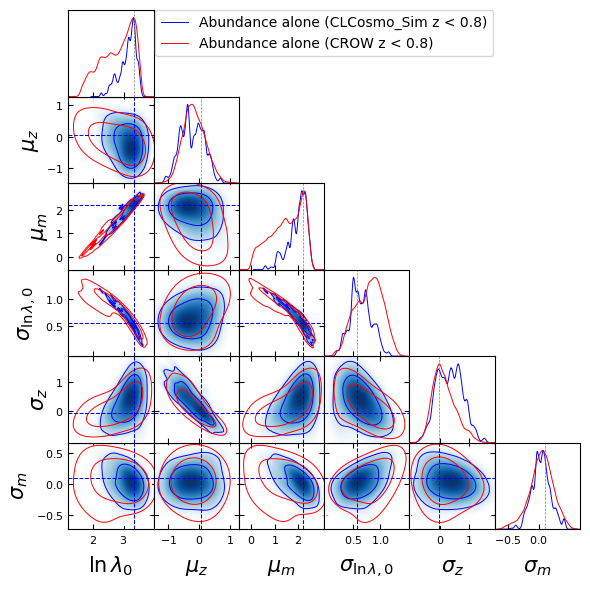

In [8]:
g = plots.get_subplot_plotter(subplot_size=1)
g.settings.lab_fontsize = 20
g.settings.legend_fontsize = 15
g.settings.axes_fontsize = 13
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
range_ = {'4': [0.2,1.1]}
g.triangle_plot(
                [N, N_eduardo ], 
                filled=[False, False, False, False, False], 
                contour_colors = ['b', 'r', 'g', 'k', 'r', 'k' ], 
                contour_ls=['-','-','-', '-', '-'],
                contour_lws=[0.7,0.7,1,1,2],shaded=True,
                legend_fontsize = 10,
                params=['1','2','3','4','5','6'],
                markers=markers,
                #param_limits = range_,
                fine_bins_2D = 5,  
                marker_args = marker_args)
#plt.savefig(f'../fig_erratum/mcmc_scaling_relation_{name}_alone.png', dpi = 300)

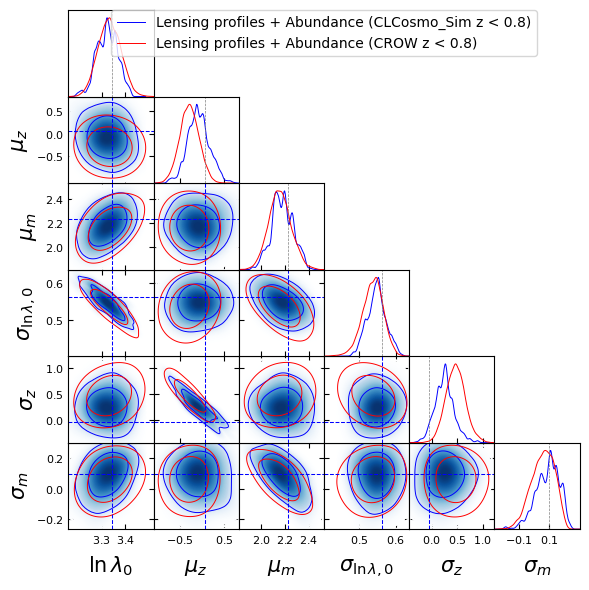

In [9]:
g = plots.get_subplot_plotter(subplot_size=1)
g.settings.lab_fontsize = 20
g.settings.legend_fontsize = 15
g.settings.axes_fontsize = 13
marker_args = {'lw':0.75, 'markersize':0.75, 'ls':'--','color':'b'}
range_ = {'4': [0.2,1.1]}
g.triangle_plot(
                [WLxN, full_eduardo ], 
                filled=[False, False, False, False, False], 
                contour_colors = ['b', 'r', 'g', 'k', 'r', 'k' ], 
                contour_ls=['-','-','-', '-', '-'],
                contour_lws=[0.7,0.7,1,1,2],shaded=True,
                legend_fontsize = 10,
                params=['1','2','3','4','5','6'],
                markers=markers,
                #param_limits = range_,
                fine_bins_2D = 5,  
                marker_args = marker_args)
#plt.savefig(f'../fig_erratum/mcmc_scaling_relation_{name}_alone.png', dpi = 300)

# Comparing parameters to fiducial values

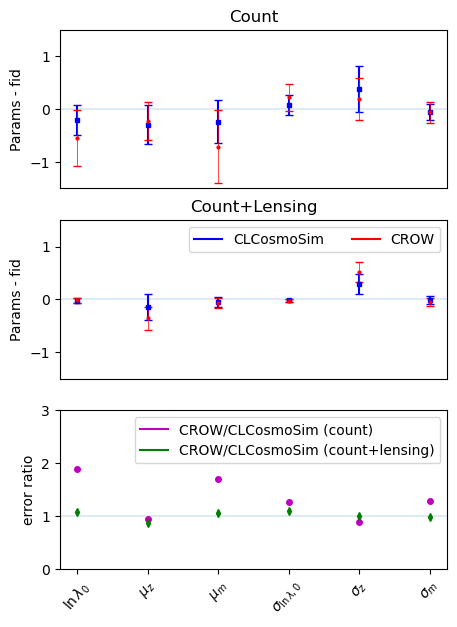

In [10]:
plt.figure(figsize=(5,7))
plt.subplot(311)
range_eduardo = ['1', '3', '2', '4', '6', '5']
plt.ylim(-1.5, 1.5)
plt.title('Count')
for i in range(len(labels)):
    
    plt.errorbar(r'$'+labels[i] + '$', N.means[i] - params_fid[i], np.sqrt(N.cov().diagonal()[i]), marker='s', color = 'b', capsize=3, markersize=3)
    plt.errorbar(r'$'+labels[i] + '$', N_eduardo.means[int(range_eduardo[i])-1] - params_fid[i], np.sqrt(N_eduardo.cov().diagonal()[int(range_eduardo[i])-1]), marker='o', color = 'r', capsize=3, lw=0.5, markersize=2)
plt.xticks([], rotation=50)
plt.axhline(0, lw=0.2)
plt.ylabel('Params - fid')
range_eduardo = ['1', '3', '2', '4', '6', '5']
plt.subplot(312)
plt.title('Count+Lensing')
plt.ylim(-1.5, 1.5)
for i in range(len(labels)):
    
    plt.errorbar(r'$'+labels[i] + '$', WLxN.means[i] - params_fid[i], np.sqrt(WLxN.cov().diagonal()[i]), marker='s', color = 'b', capsize=3, markersize=3)
    plt.errorbar(r'$'+labels[i] + '$', full_eduardo.means[int(range_eduardo[i])-1] - params_fid[i], np.sqrt(full_eduardo.cov().diagonal()[int(range_eduardo[i])-1]), marker='o', color = 'r', capsize=3, lw=0.5, markersize=2)
plt.xticks([], rotation=50)
plt.ylabel('Params - fid')
plt.axhline(0, lw=0.2)
plt.plot([], [], 'b', label = 'CLCosmoSim')
plt.plot([], [], 'r', label = 'CROW')
plt.legend(ncols=2)

plt.subplot(313)
range_eduardo = ['1', '3', '2', '4', '6', '5']
plt.ylim(0, 3)
for i in range(len(labels)):
    
    plt.errorbar(r'$'+labels[i] + '$',np.sqrt(N_eduardo.cov().diagonal()[int(range_eduardo[i])-1])/np.sqrt(N.cov().diagonal()[i]), marker='o', color = 'm', capsize=3, markersize=4)

for i in range(len(labels)):
    
    plt.errorbar(r'$'+labels[i] + '$', np.sqrt(full_eduardo.cov().diagonal()[int(range_eduardo[i])-1])/np.sqrt(WLxN.cov().diagonal()[i]), marker='d', color = 'g', capsize=3, markersize=4)

plt.xticks(rotation=50)
plt.ylabel('error ratio')
plt.axhline(1, lw=0.2)
plt.plot([], [], 'm', label = 'CROW/CLCosmoSim (count)')
plt.plot([], [], 'g', label = 'CROW/CLCosmoSim (count+lensing)')
plt.legend()
plt.show()